In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow import keras, convert_to_tensor
from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Concatenate, Normalization, StringLookup, CategoryEncoding, Dense

# Introducción a clustering con redes neuronales
## Autoencoders

Se analizará un dataset de teléfonos celulares y reseñas de clientes obtenidas de Amazon durante 2019. Contiene datos sobre los productos individuales. Incluye columnas con la siguiente información:

+ ASIN del producto
+ Marca del producto
+ Título del producto
+ URL del producto
+ URL de la imagen del producto
+ Calificación promedio del producto
+ URL de la página de reseñas del producto
+ Número total de reseñas del producto
+ Precio del producto y precio original del producto

In [ ]:
# La raw URL del CSV en GitHub
url = 'https://raw.githubusercontent.com/EduardoSelimMM/2026PrimaveraUP_ML/refs/heads/main/sesion28/amazon_items.csv'

# Se lee el CSV y se guarda en un pandas DataFrame
df = pd.read_csv(url)

In [ ]:
df.head()

,asin,brand,title,url,image,rating,reviewUrl,totalReviews,price,originalPrice
0,B0000SX2UC,NaN,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,https://www.amazon.com/Dual-Band-Tri-Mode-Acti...,https://m.media-amazon.com/images/I/2143EBQ210...,3.0,https://www.amazon.com/product-reviews/B0000SX2UC,14,0.00,0.0
1,B0009N5L7K,Motorola,Motorola I265 phone,https://www.amazon.com/Motorola-i265-I265-phon...,https://m.media-amazon.com/images/I/419WBAVDAR...,3.0,https://www.amazon.com/product-reviews/B0009N5L7K,7,49.95,0.0
2,B000SKTZ0S,Motorola,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...,https://www.amazon.com/MOTOROLA-C168i-CINGULAR...,https://m.media-amazon.com/images/I/71b+q3ydkI...,2.7,https://www.amazon.com/product-reviews/B000SKTZ0S,22,99.99,0.0
3,B001AO4OUC,Motorola,Motorola i335 Cell Phone Boost Mobile,https://www.amazon.com/Motorola-i335-Phone-Boo...,https://m.media-amazon.com/images/I/710UO8gdT+...,3.3,https://www.amazon.com/product-reviews/B001AO4OUC,21,0.00,0.0
4,B001DCJAJG,Motorola,Motorola V365 no contract cellular phone AT&T,https://www.amazon.com/Motorola-V365-contract-...,https://m.media-amazon.com/images/I/61LYNCVrrK...,3.1,https://www.amazon.com/product-reviews/B001DCJAJG,12,149.99,0.0


In [ ]:
# Ya saben nos gusta conocer las dimensiones de nuestro DataFrame
df.shape

(720, 10)

In [ ]:
# Sin mucho análisis o justificación se quitarán los NAs
df = df.dropna()

In [ ]:
# El nuevo tamaño de nuestro dataset
df.shape

(716, 10)

In [ ]:
df.columns

Index(['asin', 'brand', 'title', 'url', 'image', 'rating', 'reviewUrl',
       'totalReviews', 'price', 'originalPrice'],
      dtype='object')

+ Sólo se utilizarán las features informativas

In [ ]:
datos = df[['brand', 'title','price', 'rating', 'totalReviews', 'originalPrice']]

In [ ]:
datos.head()

,brand,title,price,rating,totalReviews,originalPrice
1,Motorola,Motorola I265 phone,49.95,3.0,7,0.0
2,Motorola,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...,99.99,2.7,22,0.0
3,Motorola,Motorola i335 Cell Phone Boost Mobile,0.00,3.3,21,0.0
4,Motorola,Motorola V365 no contract cellular phone AT&T,149.99,3.1,12,0.0
5,Nokia,Nokia 1680 Black Phone (T-Mobile),0.00,2.7,3,0.0


+ La variable `brand` es categórica, veamos qué valores únicos toma

In [ ]:
df['brand'].value_counts()

,count
brand,
Samsung,346
Motorola,105
Apple,63
Xiaomi,46
Nokia,44
Google,38
HUAWEI,32
Sony,27
OnePlus,10


+ La gran diferencia con lo que hemos visto hasta ahora con scikit-learn es que tensorflow/keras trabaja con tensores.

+ Muchas de las funciones que veremos a continuación, en realidad transforman un objeto de Python a tensor.

+ Un tensor es simplemente una estructura de datos que empaqueta números en un contenedor de múltiples dimensiones.

+ Un tensor de dimensión 0 es un escalar. Un único número "suelto". En TensorFlow, esto es un Tensor de rango 0.

+ Un tensor de dimensión 1 es un vector), i.e. una "lista" simple de números alineados. En programación es un array de una dimensión, y en TensorFlow es un Tensor de rango 1.

+ Un tensor de dimensión 2 es una matriz, i.e una "tabla" con filas y columnas. En TensorFlow, esto es un Tensor de rango 2.

+ Un tensor de dimensión 3 en arreglo estructurado en tres ejes cartesianos independientes ($X, Y, Z$).

+ Un tensor de dimensión $N$ o más (el tensor "verdadero") es una estructura de datos donde $N$ dimensiones implica formalmente que se necesita $N$ índices numéricos enteros para localizar y extraer un valor escalar único del bloque. Se conoce como Tensor de alto rango.

+ Una imagen a color es un tensor 3D: Tiene un eje para la altura (píxeles), un eje para el ancho (píxeles) y un tercer eje de profundidad para los canales de color (rojo, verde y azul).

+ Un video es un tensor 4D. Tiene altura, anchura, canales de color... y un cuarto eje para el tiempo (los fotogramas que van pasando).

### Preprocesamiento

+ Se tiene que hacer distinción entre las variables numéricas y las variables categóricas pues se convierten de manera diferente en tensores.

+ Primero vamos a crear los tensores de las variables numéricas.

In [ ]:
# Se crea un diccionario vacío para ir metiendo a los tensores
inputs = {}

for name, column in datos.items():
    dtype = column.dtype
    if dtype == object:
        dtype = tf.string # convierte el dato a string de tensorflow
    else:
        dtype = tf.float32 # convierte el dato a número de tensorflow
    inputs[name] = Input(shape=(1,), name=name, dtype=dtype)

# Se crea un diccionario vacío para ir metiendo a los tensores asociados a variables numéricas.
numeric_inputs = {}

for name, input in inputs.items():
  if input.dtype == tf.float32:
    numeric_inputs[name] = input

{'brand': <KerasTensor shape=(None, 1), dtype=string, sparse=False, ragged=False, name=brand>,
 'title': <KerasTensor shape=(None, 1), dtype=string, sparse=False, ragged=False, name=title>,
 'price': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=price>,
 'rating': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=rating>,
 'totalReviews': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=totalReviews>,
 'originalPrice': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=originalPrice>}

+ Al final, se creo un diccionario, con 4 entradas, donde cada entrada es un tensor.

In [ ]:
numeric_inputs

{'price': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=price>,
 'rating': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=rating>,
 'totalReviews': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=totalReviews>,
 'originalPrice': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=originalPrice>}

+ Haremos la normalización (tensorial) para las variables numéricas.

In [ ]:
x = Concatenate()(list(numeric_inputs.values()))
# Se genera el objeto normalización de TensorFlow
norm = Normalization()
# Se aplica la normalización a las variables numéticas
norm.adapt(np.array(datos[numeric_inputs.keys()]))
inputs_numericos = norm(x)

In [ ]:
inputs_numericos

<KerasTensor shape=(None, 4), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>

In [ ]:
preprocessed_inputs = [inputs_numericos]

In [ ]:
preprocessed_inputs

[<KerasTensor shape=(None, 4), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>]

+ Ahora haremos el preprocesamiento de variables categóricas. Básicamente convertir a variable dummy/one-hot-encoding.

In [ ]:
for name, input in inputs.items():
    if input.dtype != tf.string:
        continue

    lookup = StringLookup(vocabulary=np.unique(datos[name]))
    one_hot = CategoryEncoding(num_tokens=lookup.vocabulary_size())
    x = lookup(input)
    x = one_hot(x)
    preprocessed_inputs.append(x)

In [ ]:
preprocessed_inputs

[<KerasTensor shape=(None, 4), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>,
 <KerasTensor shape=(None, 11), dtype=float32, sparse=False, ragged=False, name=keras_tensor_3>,
 <KerasTensor shape=(None, 715), dtype=float32, sparse=False, ragged=False, name=keras_tensor_5>]

In [ ]:
preprocessed_inputs_todas = Concatenate()(preprocessed_inputs)
preprocessing_layer = Model(inputs, preprocessed_inputs_todas, name = "ProcessData")

In [ ]:
preprocessing_layer

<Functional name=ProcessData, built=True>

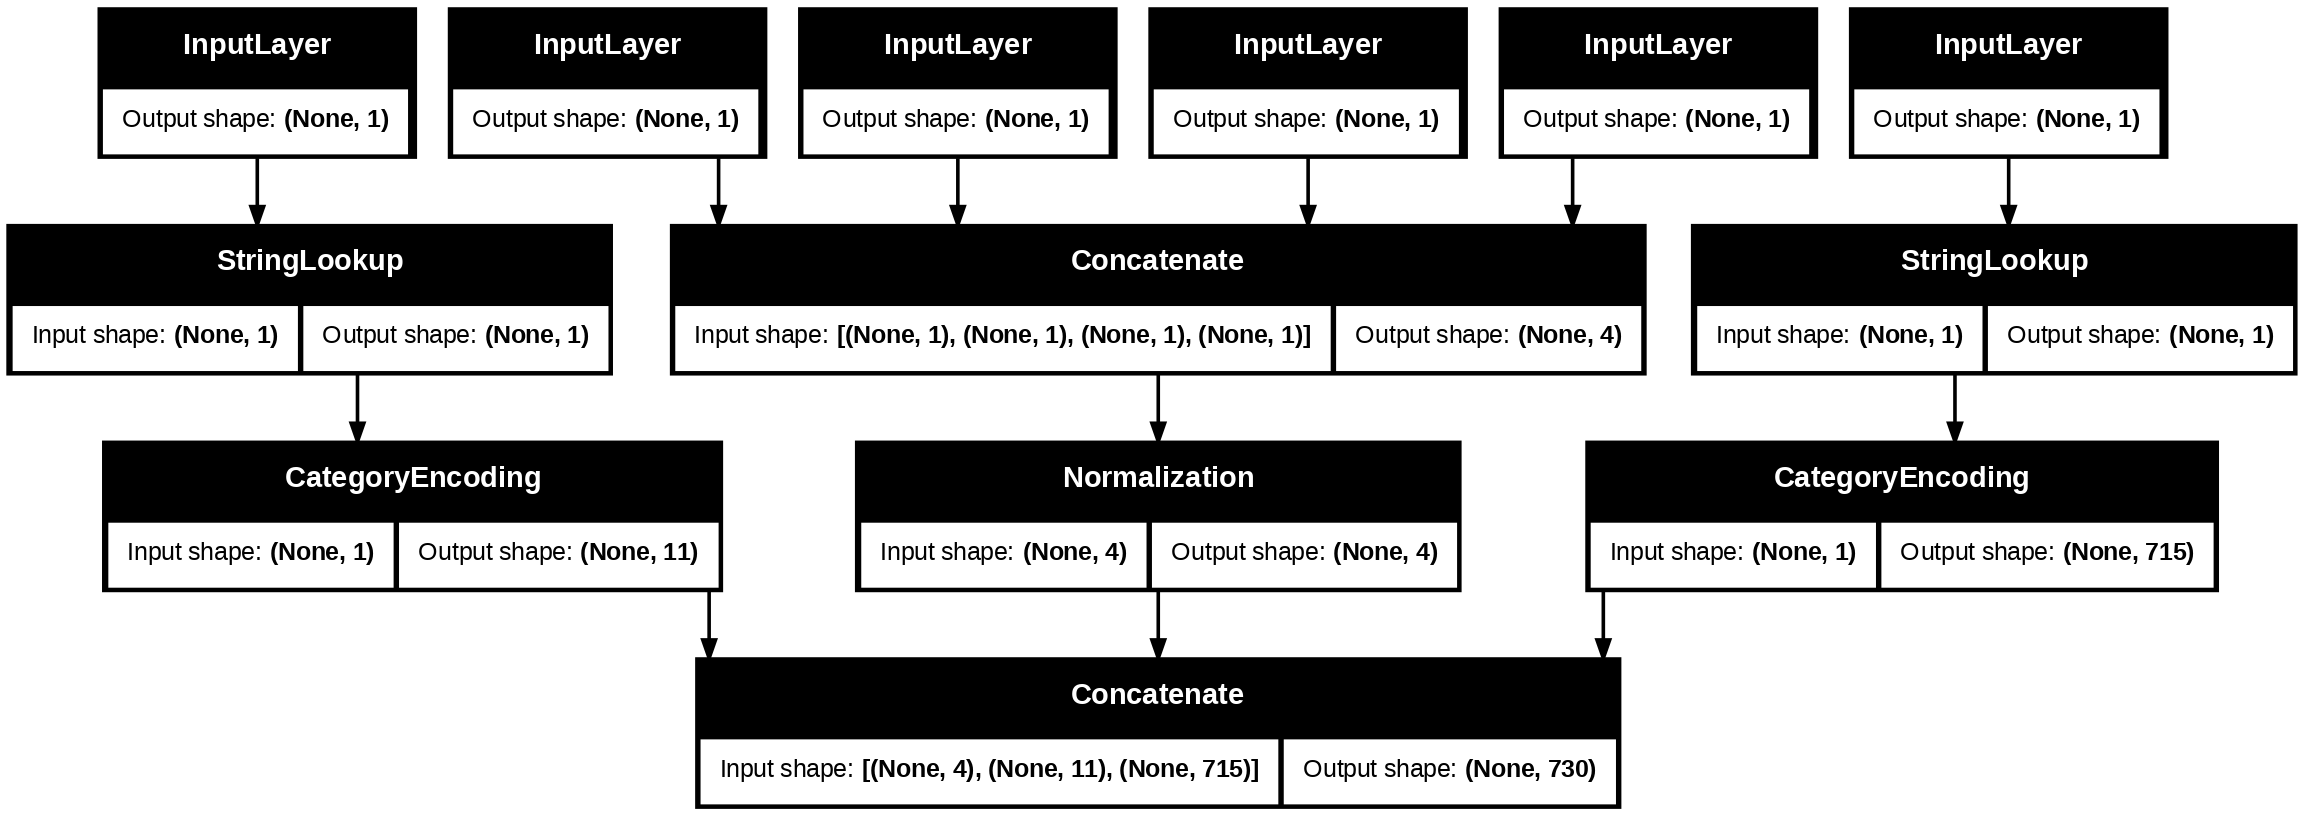

In [ ]:
keras.utils.plot_model(
    model = preprocessing_layer,
    rankdir = "TB",
    dpi = 130,
    show_shapes = True
)

In [ ]:
full_dim = preprocessing_layer.output.shape[-1]

In [ ]:
full_dim

730

### Autoencoder

+ Tiene una parte de codificación.
+ Una parte de cuello de botella.
+ y una parte de decodificación.

In [ ]:
encoder_model = Sequential([
    Input(shape=(full_dim,)),
    Dense(128, activation = 'relu'),
    Dense(16, activation = 'relu'),
    Dense(3, activation = 'relu', name = "LatentSpaceLayer")
], name = "Encoder")

decoder_model = Sequential([
    # IMPORTANTE: Debe coincidir con la dimensión de la última capa del encoder
    Input(shape=(3,)),
    # Espejo del Encoder: sube de 3 a 16, y luego de 16 a 128 neuronas
    Dense(16, activation = 'relu'),
    Dense(128, activation = 'relu'),
    # La capa de salida debe recuperar EXACTAMENTE el tamaño original de los datos
    Dense(full_dim, activation = 'sigmoid', name = "ReconstructionLayer")
], name="Decoder")

In [ ]:
##### Juntamos todo #####
# Se define la entrada global del sistema
autoencoder_input = Input(shape=(full_dim,))

# Se conectan los bloques de encoding y decoding
encoded_repr = encoder_model(autoencoder_input)
decoded_repr = decoder_model(encoded_repr)

# Se crea el modelo final completo
autoencoder_model = Model(
    inputs = autoencoder_input,
    outputs = decoded_repr,
    name = "Autoencoder"
)

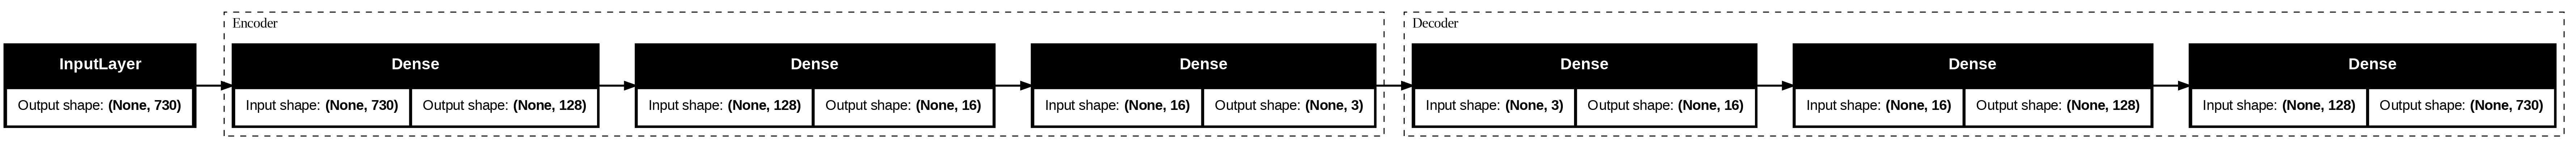

In [ ]:
keras.utils.plot_model(
    autoencoder_model,
    rankdir = "LR",
    show_shapes = True,
    expand_nested = True
)

In [ ]:
# Compilamos el autoencoder completo
autoencoder_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'mean_squared_error', # Mide qué tanto se parecen los datos reales a los reconstruidos
    metrics = ['accuracy', 'mae']
)

In [ ]:
# Convertimos cada columna del DataFrame en un tensor de TensorFlow
items_features_dict = {name: convert_to_tensor(value) for name, value in datos.items()}

In [ ]:
p_items = preprocessing_layer(items_features_dict).numpy()

#
train_data, test_data = train_test_split(
    p_items,
    train_size = 0.8,
    random_state = 2026
)

In [ ]:
# Es una convención llamarle 'history' a la parte del .fit
history = autoencoder_model.fit(
    x = train_data,
    y = train_data,
    epochs = 100,
    batch_size = 256,
    shuffle = True,
    validation_data = (test_data, test_data)
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.0000e+00 - loss: 0.2553 - mae: 0.5020 - val_accuracy: 0.0000e+00 - val_loss: 0.2536 - val_mae: 0.5007
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0000e+00 - loss: 0.2535 - mae: 0.5002 - val_accuracy: 0.0000e+00 - val_loss: 0.2509 - val_mae: 0.4980
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0000e+00 - loss: 0.2503 - mae: 0.4970 - val_accuracy: 0.0000e+00 - val_loss: 0.2465 - val_mae: 0.4935
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0000e+00 - loss: 0.2453 - mae: 0.4919 - val_accuracy: 0.0000e+00 - val_loss: 0.2398 - val_mae: 0.4866
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0962 - loss: 0.2376 - mae: 0.4839 - val_accuracy: 0.3125 - val_loss: 0.2301 - val_mae: 0.4764
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2832 - loss: 0.2265 - mae: 0.4721 - val_accuracy: 0.3125 - val_loss: 0.2166 - val_mae: 0.4617
Epoch 7/100
3/3 ━━━

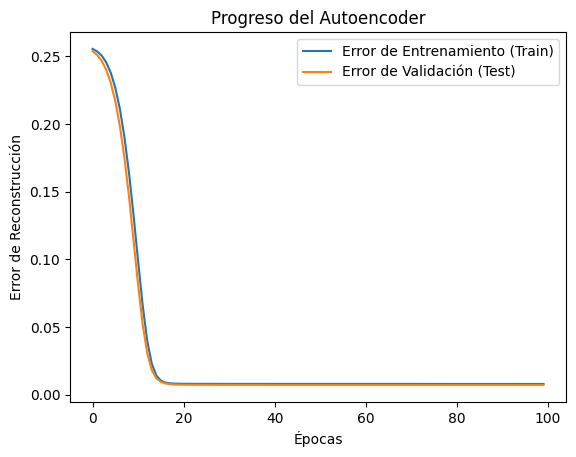

In [ ]:
# Graficamos el error de entrenamiento vs el de validación
plt.plot(history.history['loss'], label='Error de Entrenamiento (Train)')
plt.plot(history.history['val_loss'], label='Error de Validación (Test)')

plt.title('Progreso del Autoencoder')
plt.xlabel('Épocas')
plt.ylabel('Error de Reconstrucción')
plt.legend()
plt.show()

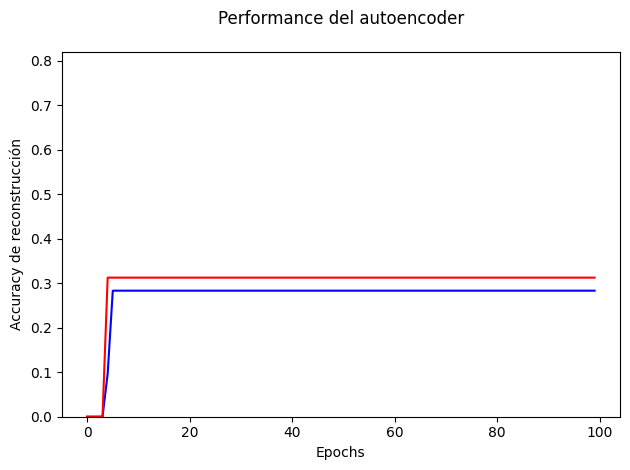

In [ ]:
# Se grafica la precisión de entrenamiento (azul) y validación (rojo)
plt.plot(history.history['accuracy'], color = 'blue', label = 'Train')
plt.plot(history.history['val_accuracy'], color = 'red', label = 'Validation')

# Títulos y etiquetas de los ejes
plt.title('Performance del autoencoder', pad = 20, fontsize = 12)
plt.ylabel('Accuracy de reconstrucción', fontsize = 10)
plt.xlabel('Epochs', fontsize = 10)

plt.ylim(0.0, 0.82)
plt.tight_layout()
plt.show()

In [ ]:
datos_latentes = encoder_model.predict(train_data)

print("Forma original:", train_data.shape)
print("Forma comprimida (latente):", datos_latentes.shape)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Forma original: (572, 730)
Forma comprimida (latente): (572, 3)


### Clustering con K-medias en el espacio "reducido"

In [ ]:
# Se prueba con varios valores de K:
suma_de_dist_cuadradas = []
K = range(1,30)
for k in K:
    km = KMeans(init='k-means++', n_clusters=k, n_init=10)
    km.fit(datos_latentes)
    suma_de_dist_cuadradas.append(km.inertia_)

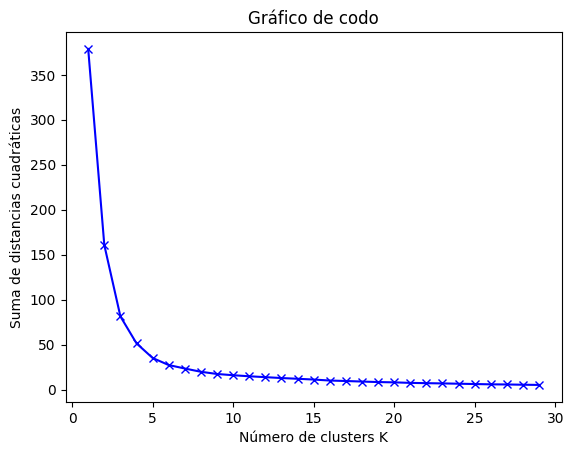

In [ ]:
plt.plot(K, suma_de_dist_cuadradas, 'bx-')
plt.xlabel('Número de clusters K')
plt.ylabel('Suma de distancias cuadráticas')
plt.title('Gráfico de codo')
plt.show()

In [ ]:
n_clusters = 4
kmeans = KMeans(n_clusters = n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(datos_latentes)

In [ ]:
# Se crea un DataFrame con las 3 dimensiones y las etiquetas de los clusters.
df_3d = pd.DataFrame(datos_latentes, columns=['Dim 1', 'Dim 2', 'Dim 3'])
df_3d['Cluster'] = cluster_labels.astype(str) # Se convierte a string para que Plotly use colores discretos

# Creación de la gráfica interactiva en 3D
fig = px.scatter_3d(
    df_3d,
    x = 'Dim 1',
    y = 'Dim 2',
    z = 'Dim 3',
    color = 'Cluster', # Los puntos se colorean según su grupo
    color_discrete_sequence = px.colors.qualitative.Vivid, # Paleta de colores vivos
    title = 'Visualización interactiva 3D de los clusters',
    opacity = 0.7
)

# Detalles estéticos
fig.update_traces(marker=dict(size=4)) # Ajusta el tamaño de las esferas
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40), # Aprovecha todo el espacio disponible
    scene=dict(
        xaxis_title = 'Dimensión Latente 1',
        yaxis_title = 'Dimensión Latente 2',
        zaxis_title = 'Dimensión Latente 3'
    )
)

fig.show()